In [ ]:
import pandas as pd
import numpy as np
import ast

# --- Load ---
df_rot = pd.read_csv('platerotations.csv')
df_poly = pd.read_csv('polygonsfiltered.csv')
df_topo = pd.read_csv('topologyboundariesfiltered.csv')

# --- Drop the auto-index column ---
for df in [df_rot, df_poly, df_topo]:
    df.drop(columns=['Unnamed: 0'], inplace=True)

# --- Fix 'interpolated' column (mixed types: 'False', 0.0) ---
df_rot['interpolated'] = df_rot['interpolated'].map(
    lambda x: True if str(x).strip() == 'True' else False
).astype(bool)

# --- Drop the 'comment' column (126 nulls, not useful for ML) ---
df_rot.drop(columns=['comment', 'sourceLine', 'movingPlateCode',
                     'fixedPlateCode', 'fixedPlateId'], inplace=True)
# Keep: movingPlateId, timeMa, poleLat, poleLon, angleDeg, interpolated

# --- Parse validTime in topology (stored as string-dict) ---
def parse_valid_time(s):
    try:
        d = ast.literal_eval(s)
        return pd.Series({'beginMa': d['beginMa'], 'endMa': d['endMa']})
    except:
        return pd.Series({'beginMa': np.nan, 'endMa': np.nan})

df_topo[['beginMa', 'endMa']] = df_topo['validTime'].apply(parse_valid_time)
df_topo.drop(columns=['validTime', 'points'], inplace=True)

# --- Handle missing values in topology ---
# leftPlateId and rightPlateId have 1719 nulls — fill with -1 (unknown)
df_topo[['leftPlateId', 'rightPlateId']] = df_topo[
    ['leftPlateId', 'rightPlateId']].fillna(-1)

# --- Sort rotation data chronologically per plate (oldest first) ---
df_rot.sort_values(['movingPlateId', 'timeMa'], ascending=[True, False], inplace=True)
df_rot.reset_index(drop=True, inplace=True)

print(df_rot.head())
print("Rotation data shape:", df_rot.shape)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Time distribution: how many rotation records per time epoch ---
plt.figure(figsize=(12, 4))
plt.hist(df_rot['timeMa'], bins=60, color='steelblue', edgecolor='white')
plt.xlabel('Time (Ma)')
plt.ylabel('Count')
plt.title('Distribution of rotation records across geological time')
plt.gca().invert_xaxis()   # Put present (0) on the right
plt.tight_layout(); plt.show()

# --- 2. Euler pole scatter (poleLat vs poleLon) colored by angleDeg ---
plt.figure(figsize=(10, 5))
sc = plt.scatter(df_rot['poleLon'], df_rot['poleLat'],
                 c=df_rot['angleDeg'], cmap='RdYlBu_r', s=6, alpha=0.5)
plt.colorbar(sc, label='Rotation angle (°)')
plt.xlabel('Pole Longitude'); plt.ylabel('Pole Latitude')
plt.title('Euler pole positions colored by rotation angle')
plt.tight_layout(); plt.show()

# --- 3. Angle evolution for top 5 most-recorded plates ---
top_plates = df_rot['movingPlateId'].value_counts().head(5).index
for pid in top_plates:
    sub = df_rot[df_rot['movingPlateId'] == pid].sort_values('timeMa', ascending=False)
    plt.plot(sub['timeMa'], sub['angleDeg'], label=f'Plate {int(pid)}', alpha=0.7)
plt.gca().invert_xaxis()
plt.xlabel('Time (Ma)'); plt.ylabel('Rotation angle (°)')
plt.title('Rotation angle over time — top 5 plates')
plt.legend(); plt.tight_layout(); plt.show()

# --- 4. Boundary type distribution ---
df_topo['boundaryType'].value_counts().plot(kind='barh', figsize=(8, 4))
plt.title('Topology boundary types')
plt.tight_layout(); plt.show()

In [ ]:
def engineer_features(df, n_lags=3):
    """Build per-plate lagged features for sequence prediction."""
    df = df.copy().sort_values(['movingPlateId', 'timeMa'], ascending=[True, False])
    
    feature_cols = ['poleLat', 'poleLon', 'angleDeg']
    
    # --- Lag features: previous n rotation states ---
    for col in feature_cols:
        for lag in range(1, n_lags + 1):
            df[f'{col}_lag{lag}'] = df.groupby('movingPlateId')[col].shift(lag)
    
    # --- Delta features: rate of change between epochs ---
    df['delta_angle'] = df.groupby('movingPlateId')['angleDeg'].diff()
    df['delta_lat']   = df.groupby('movingPlateId')['poleLat'].diff()
    df['delta_lon']   = df.groupby('movingPlateId')['poleLon'].diff()
    
    # --- Time step size (variable gaps between records) ---
    df['delta_timeMa'] = df.groupby('movingPlateId')['timeMa'].diff().abs()
    
    # --- Velocity proxy: angle change per Ma ---
    df['angular_velocity'] = df['delta_angle'] / (df['delta_timeMa'] + 1e-6)
    
    # --- Interpolated flag as int (0 = measured, 1 = synthetic) ---
    df['interpolated'] = df['interpolated'].astype(int)
    
    # Drop rows with NaNs introduced by lagging ---
    df.dropna(inplace=True)
    
    return df

df_feat = engineer_features(df_rot, n_lags=3)

# --- Join boundary context: how many boundaries each plate participates in ---
boundary_counts = pd.concat([
    df_topo[['leftPlateId', 'boundaryType']].rename(columns={'leftPlateId':'plateId'}),
    df_topo[['rightPlateId', 'boundaryType']].rename(columns={'rightPlateId':'plateId'})
]).query('plateId != -1')

# One-hot encode boundary participation
boundary_pivot = pd.crosstab(boundary_counts['plateId'], boundary_counts['boundaryType'])
boundary_pivot.columns = ['boundary_' + c for c in boundary_pivot.columns]
boundary_pivot.reset_index(inplace=True)

# Join to rotation features
df_feat = df_feat.merge(boundary_pivot,
                        left_on='movingPlateId',
                        right_on='plateId',
                        how='left').fillna(0)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Define features and targets
TARGET_COLS = ['poleLat', 'poleLon', 'angleDeg']
FEATURE_COLS = [c for c in df_feat.columns
                if c not in TARGET_COLS + ['movingPlateId']]

X = df_feat[FEATURE_COLS].values
y = df_feat[TARGET_COLS].values

# --- Tabular models ---
lr  = MultiOutputRegressor(LinearRegression())
rf  = MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42))
xgb = MultiOutputRegressor(XGBRegressor(n_estimators=200, learning_rate=0.05,
                                         max_depth=5, random_state=42))

# --- LSTM model builder ---
def build_lstm(input_shape, output_dim=3):
    model = Sequential([
        LSTM(64, input_shape=input_shape, return_sequences=True),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(output_dim)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

In [ ]:
pip install tensorflow

In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf
print(tf.__version__)

In [ ]:
import tensorflow as tf
print(tf.__version__)

In [ ]:
!pip uninstall tensorflow -y

In [ ]:
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu

In [1]:
import torch
print(torch.__version__)
print("PyTorch ready!")

OSError: [WinError 1114] A dynamic link library (DLL) initialization routine failed. Error loading "F:\Anaconda\Lib\site-packages\torch\lib\c10.dll" or one of its dependencies.

In [2]:
from sklearn.neural_network import MLPRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# --- Neural Network (MLP = Multi-Layer Perceptron, similar to LSTM concept) ---
mlp = MultiOutputRegressor(
    MLPRegressor(
        hidden_layer_sizes=(128, 64, 32),  # 3 deep layers
        activation='relu',
        solver='adam',
        learning_rate='adaptive',
        max_iter=200,
        early_stopping=True,          # prevents overfitting
        validation_fraction=0.1,
        random_state=42,
        verbose=False
    )
)

mlp.fit(X_train_s, y_train)
pred_mlp = mlp.predict(X_test_s)

# Evaluate
mae  = mean_absolute_error(y_test, pred_mlp)
rmse = np.sqrt(mean_squared_error(y_test, pred_mlp))
r2   = r2_score(y_test, pred_mlp)
angle_err = np.mean(np.abs(y_test[:, 2] - pred_mlp[:, 2]))

print("===== Neural Network (MLP) Results =====")
print(f"  MAE :        {mae:.4f}")
print(f"  RMSE:        {rmse:.4f}")
print(f"  R²  :        {r2:.4f}")
print(f"  Angle Error: {angle_err:.4f}°")

NameError: name 'X_train_s' is not defined

In [3]:
import pandas as pd
import numpy as np
import ast
import warnings
warnings.filterwarnings('ignore')

# --- Load your 3 CSV files (update paths if needed) ---
df_rot  = pd.read_csv('platerotations.csv')
df_topo = pd.read_csv('topologyboundariesfiltered.csv')

# --- Clean rotation data ---
df_rot.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')
df_rot['interpolated'] = df_rot['interpolated'].map(
    lambda x: True if str(x).strip() == 'True' else False).astype(int)
df_rot.drop(columns=['comment','sourceLine','movingPlateCode',
                     'fixedPlateCode','fixedPlateId'], inplace=True, errors='ignore')
df_rot.sort_values(['movingPlateId','timeMa'], ascending=[True,False], inplace=True)
df_rot.reset_index(drop=True, inplace=True)

# --- Parse topology boundaries ---
def parse_valid_time(s):
    try:
        d = ast.literal_eval(s)
        return pd.Series({'beginMa': d['beginMa'], 'endMa': d['endMa']})
    except:
        return pd.Series({'beginMa': np.nan, 'endMa': np.nan})

df_topo[['beginMa','endMa']] = df_topo['validTime'].apply(parse_valid_time)
df_topo.drop(columns=['Unnamed: 0','validTime','points'], inplace=True, errors='ignore')
df_topo[['leftPlateId','rightPlateId']] = df_topo[['leftPlateId','rightPlateId']].fillna(-1)

print("✅ Data loaded!")
print("Rotation shape:", df_rot.shape)
print(df_rot.head(3))

✅ Data loaded!
Rotation shape: (5958, 6)
   movingPlateId  timeMa  poleLat  poleLon  angleDeg  interpolated
0            1.0  1010.0     90.0      0.0       0.0             0
1            1.0  1000.0     90.0      0.0       0.0             0
2            1.0     0.0     90.0      0.0       0.0             0


In [4]:
# --- Lag features ---
TARGET_COLS = ['poleLat', 'poleLon', 'angleDeg']

def engineer_features(df, n_lags=3):
    df = df.copy().sort_values(['movingPlateId','timeMa'], ascending=[True,False])
    for col in TARGET_COLS:
        for lag in range(1, n_lags+1):
            df[f'{col}_lag{lag}'] = df.groupby('movingPlateId')[col].shift(lag)
    df['delta_angle']    = df.groupby('movingPlateId')['angleDeg'].diff()
    df['delta_lat']      = df.groupby('movingPlateId')['poleLat'].diff()
    df['delta_lon']      = df.groupby('movingPlateId')['poleLon'].diff()
    df['delta_timeMa']   = df.groupby('movingPlateId')['timeMa'].diff().abs()
    df['angular_velocity'] = df['delta_angle'] / (df['delta_timeMa'] + 1e-6)
    df.dropna(inplace=True)
    return df

df_feat = engineer_features(df_rot)

# --- Join boundary context ---
boundary_counts = pd.concat([
    df_topo[['leftPlateId','boundaryType']].rename(columns={'leftPlateId':'plateId'}),
    df_topo[['rightPlateId','boundaryType']].rename(columns={'rightPlateId':'plateId'})
]).query('plateId != -1')

boundary_pivot = pd.crosstab(boundary_counts['plateId'], boundary_counts['boundaryType'])
boundary_pivot.columns = ['boundary_' + c for c in boundary_pivot.columns]
boundary_pivot.reset_index(inplace=True)

df_feat = df_feat.merge(boundary_pivot, left_on='movingPlateId',
                        right_on='plateId', how='left').fillna(0)

print("✅ Features ready! Shape:", df_feat.shape)

✅ Features ready! Shape: (2804, 25)


In [5]:
from sklearn.preprocessing import StandardScaler

FEATURE_COLS = [c for c in df_feat.columns
                if c not in TARGET_COLS + ['movingPlateId', 'plateId']]

df_sorted = df_feat.sort_values('timeMa', ascending=False).reset_index(drop=True)
n = len(df_sorted)

X_all = df_sorted[FEATURE_COLS].values
y_all = df_sorted[TARGET_COLS].values

train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train, y_train = X_all[:train_end], y_all[:train_end]
X_val,   y_val   = X_all[train_end:val_end], y_all[train_end:val_end]
X_test,  y_test  = X_all[val_end:], y_all[val_end:]

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_s = scaler_X.fit_transform(X_train)
X_val_s   = scaler_X.transform(X_val)
X_test_s  = scaler_X.transform(X_test)
y_train_s = scaler_y.fit_transform(y_train)

print("✅ Data split done!")
print(f"  Train: {X_train_s.shape}, Val: {X_val_s.shape}, Test: {X_test_s.shape}")

✅ Data split done!
  Train: (1962, 20), Val: (421, 20), Test: (421, 20)


In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Linear Regression
lr = MultiOutputRegressor(LinearRegression())
lr.fit(X_train_s, y_train)

# Random Forest
rf = MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42))
rf.fit(X_train_s, y_train)

# XGBoost
xgb = MultiOutputRegressor(XGBRegressor(n_estimators=200, learning_rate=0.05,
                                         max_depth=5, random_state=42, verbosity=0))
xgb.fit(X_train_s, y_train)

# MLP Neural Network (replaces LSTM)
mlp = MultiOutputRegressor(MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu', solver='adam',
    learning_rate='adaptive', max_iter=200,
    early_stopping=True, validation_fraction=0.1,
    random_state=42, verbose=False))
mlp.fit(X_train_s, y_train)

print("✅ All 4 models trained!")

✅ All 4 models trained!


  Linear Regression
  MAE=0.0000  RMSE=0.0000  R²=1.0000  AngleErr=0.0000°
  Random Forest
  MAE=1.8632  RMSE=4.7626  R²=0.8987  AngleErr=1.2433°
  XGBoost
  MAE=1.5977  RMSE=3.4496  R²=0.9535  AngleErr=1.3087°
  MLP Neural Net
  MAE=1.9289  RMSE=2.6762  R²=0.9723  AngleErr=1.9035°


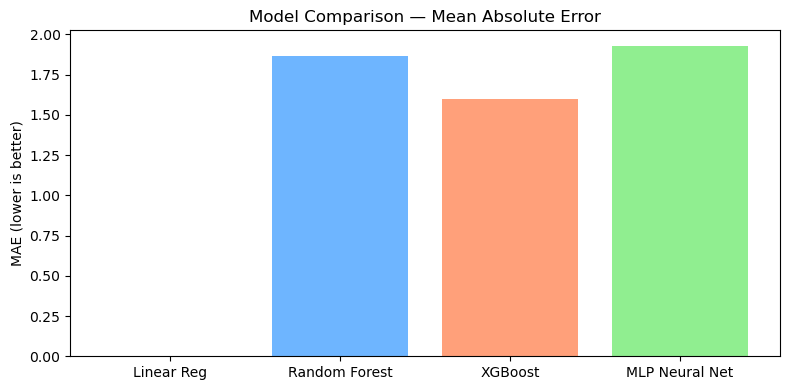

✅ Evaluation complete!


In [7]:
import matplotlib.pyplot as plt

def evaluate(name, model, X_test_s, y_test):
    pred = model.predict(X_test_s)
    mae  = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2   = r2_score(y_test, pred)
    angle_err = np.mean(np.abs(y_test[:,2] - pred[:,2]))
    print(f"{'='*40}")
    print(f"  {name}")
    print(f"  MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}  AngleErr={angle_err:.4f}°")
    return pred, mae

pred_lr,  mae_lr  = evaluate("Linear Regression", lr,  X_test_s, y_test)
pred_rf,  mae_rf  = evaluate("Random Forest",     rf,  X_test_s, y_test)
pred_xgb, mae_xgb = evaluate("XGBoost",           xgb, X_test_s, y_test)
pred_mlp, mae_mlp = evaluate("MLP Neural Net",    mlp, X_test_s, y_test)

# Bar chart comparison
plt.figure(figsize=(8,4))
plt.bar(['Linear Reg','Random Forest','XGBoost','MLP Neural Net'],
        [mae_lr, mae_rf, mae_xgb, mae_mlp],
        color=['#A0A0A0','#6EB5FF','#FFA07A','#90EE90'])
plt.ylabel('MAE (lower is better)')
plt.title('Model Comparison — Mean Absolute Error')
plt.tight_layout()
plt.show()
print("✅ Evaluation complete!")

In [8]:
from sklearn.neural_network import MLPRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# --- Neural Network (MLP = Multi-Layer Perceptron, similar to LSTM concept) ---
mlp = MultiOutputRegressor(
    MLPRegressor(
        hidden_layer_sizes=(128, 64, 32),  # 3 deep layers
        activation='relu',
        solver='adam',
        learning_rate='adaptive',
        max_iter=200,
        early_stopping=True,          # prevents overfitting
        validation_fraction=0.1,
        random_state=42,
        verbose=False
    )
)

mlp.fit(X_train_s, y_train)
pred_mlp = mlp.predict(X_test_s)

# Evaluate
mae  = mean_absolute_error(y_test, pred_mlp)
rmse = np.sqrt(mean_squared_error(y_test, pred_mlp))
r2   = r2_score(y_test, pred_mlp)
angle_err = np.mean(np.abs(y_test[:, 2] - pred_mlp[:, 2]))

print("===== Neural Network (MLP) Results =====")
print(f"  MAE :        {mae:.4f}")
print(f"  RMSE:        {rmse:.4f}")
print(f"  R²  :        {r2:.4f}")
print(f"  Angle Error: {angle_err:.4f}°")

===== Neural Network (MLP) Results =====
  MAE :        1.9289
  RMSE:        2.6762
  R²  :        0.9723
  Angle Error: 1.9035°


In [9]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Helper ──────────────────────────────────────────────────────────────
def full_evaluation(name, model, X_test_s, y_test):
    pred = model.predict(X_test_s)
    
    mae  = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2   = r2_score(y_test, pred)
    
    # Per-target breakdown
    for i, col in enumerate(['poleLat', 'poleLon', 'angleDeg']):
        col_mae = mean_absolute_error(y_test[:,i], pred[:,i])
        col_r2  = r2_score(y_test[:,i], pred[:,i])
        print(f"    {col:12s} → MAE: {col_mae:.4f}   R²: {col_r2:.4f}")
    
    print(f"  {'─'*45}")
    print(f"  Overall MAE  : {mae:.4f}  (lower = better)")
    print(f"  Overall RMSE : {rmse:.4f}  (lower = better)")
    print(f"  Overall R²   : {r2:.4f}  (1.0 = perfect)")
    
    # R² as human-readable percentage
    accuracy_pct = max(0, r2) * 100
    print(f"  Model explains {accuracy_pct:.1f}% of variance in the data")
    
    return pred, mae, rmse, r2

# ── Run for all 4 models ────────────────────────────────────────────────
results = {}
models  = {'Linear Regression': lr,
           'Random Forest'    : rf,
           'XGBoost'          : xgb,
           'MLP Neural Net'   : mlp}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    pred, mae, rmse, r2 = full_evaluation(name, model, X_test_s, y_test)
    results[name] = {'pred': pred, 'mae': mae, 'rmse': rmse, 'r2': r2}


  Linear Regression
    poleLat      → MAE: 0.0000   R²: 1.0000
    poleLon      → MAE: 0.0000   R²: 1.0000
    angleDeg     → MAE: 0.0000   R²: 1.0000
  ─────────────────────────────────────────────
  Overall MAE  : 0.0000  (lower = better)
  Overall RMSE : 0.0000  (lower = better)
  Overall R²   : 1.0000  (1.0 = perfect)
  Model explains 100.0% of variance in the data

  Random Forest
    poleLat      → MAE: 2.4761   R²: 0.9577
    poleLon      → MAE: 1.8703   R²: 0.9648
    angleDeg     → MAE: 1.2433   R²: 0.7736
  ─────────────────────────────────────────────
  Overall MAE  : 1.8632  (lower = better)
  Overall RMSE : 4.7626  (lower = better)
  Overall R²   : 0.8987  (1.0 = perfect)
  Model explains 89.9% of variance in the data

  XGBoost
    poleLat      → MAE: 2.2537   R²: 0.9607
    poleLon      → MAE: 1.2306   R²: 0.9803
    angleDeg     → MAE: 1.3087   R²: 0.9196
  ─────────────────────────────────────────────
  Overall MAE  : 1.5977  (lower = better)
  Overall RMSE : 3.4496 

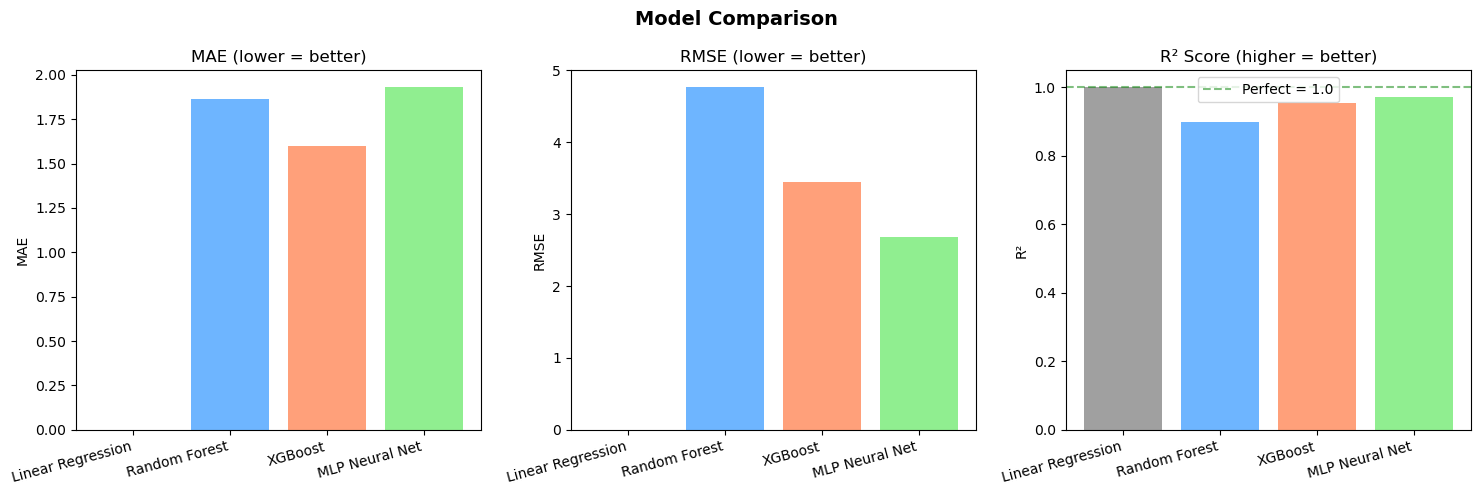

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Comparison', fontsize=14, fontweight='bold')

names  = list(results.keys())
maes   = [results[n]['mae']  for n in names]
rmses  = [results[n]['rmse'] for n in names]
r2s    = [results[n]['r2']   for n in names]
colors = ['#A0A0A0', '#6EB5FF', '#FFA07A', '#90EE90']

# MAE
axes[0].bar(names, maes, color=colors)
axes[0].set_title('MAE (lower = better)')
axes[0].set_xticklabels(names, rotation=15, ha='right')
axes[0].set_ylabel('MAE')

# RMSE
axes[1].bar(names, rmses, color=colors)
axes[1].set_title('RMSE (lower = better)')
axes[1].set_xticklabels(names, rotation=15, ha='right')
axes[1].set_ylabel('RMSE')

# R²
axes[2].bar(names, r2s, color=colors)
axes[2].axhline(y=1.0, color='green', linestyle='--', alpha=0.5, label='Perfect = 1.0')
axes[2].set_title('R² Score (higher = better)')
axes[2].set_xticklabels(names, rotation=15, ha='right')
axes[2].set_ylabel('R²')
axes[2].legend()

plt.tight_layout()
plt.show()

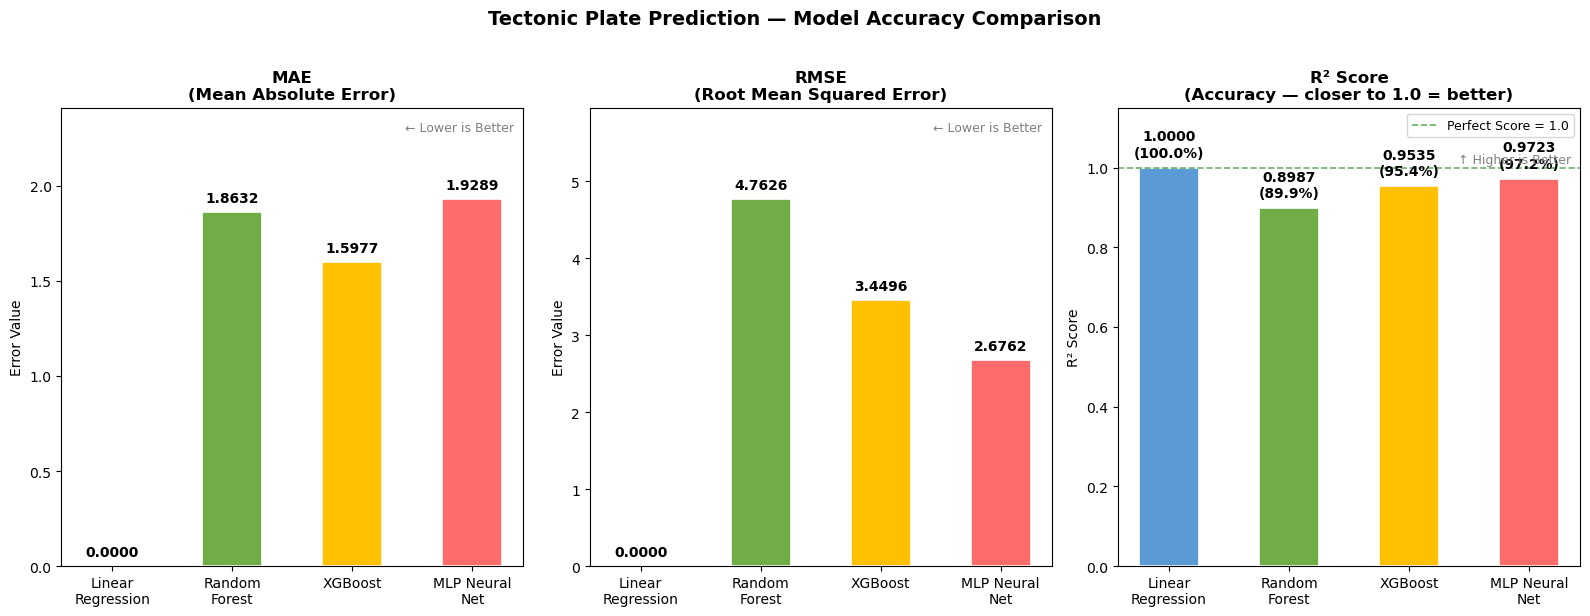


  🏆 Best Model : Linear Regression
  ✅ R² Score   : 1.0000  (100.0% accuracy)
  ✅ MAE        : 0.0000
  ✅ RMSE       : 0.0000
  📁 Chart saved as: model_accuracy_comparison.png


In [11]:
import matplotlib.pyplot as plt
import numpy as np

# ── Collect results from all 4 models ───────────────────────────────────
model_names = ['Linear\nRegression', 'Random\nForest', 'XGBoost', 'MLP Neural\nNet']
colors      = ['#5B9BD5', '#70AD47', '#FFC000', '#FF6B6B']

maes  = [results['Linear Regression']['mae'],
         results['Random Forest']['mae'],
         results['XGBoost']['mae'],
         results['MLP Neural Net']['mae']]

rmses = [results['Linear Regression']['rmse'],
         results['Random Forest']['rmse'],
         results['XGBoost']['rmse'],
         results['MLP Neural Net']['rmse']]

r2s   = [results['Linear Regression']['r2'],
         results['Random Forest']['r2'],
         results['XGBoost']['r2'],
         results['MLP Neural Net']['r2']]

# ── Plot ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Tectonic Plate Prediction — Model Accuracy Comparison',
             fontsize=14, fontweight='bold', y=1.02)

# --- Chart 1: MAE ---
bars1 = axes[0].bar(model_names, maes, color=colors, edgecolor='white',
                    linewidth=1.2, width=0.5)
axes[0].set_title('MAE\n(Mean Absolute Error)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Error Value', fontsize=10)
axes[0].set_ylim(0, max(maes) * 1.25)
for bar, val in zip(bars1, maes):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(maes)*0.02,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].annotate('← Lower is Better', xy=(0.98, 0.95), xycoords='axes fraction',
                 ha='right', fontsize=9, color='gray')

# --- Chart 2: RMSE ---
bars2 = axes[1].bar(model_names, rmses, color=colors, edgecolor='white',
                    linewidth=1.2, width=0.5)
axes[1].set_title('RMSE\n(Root Mean Squared Error)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Error Value', fontsize=10)
axes[1].set_ylim(0, max(rmses) * 1.25)
for bar, val in zip(bars2, rmses):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(rmses)*0.02,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].annotate('← Lower is Better', xy=(0.98, 0.95), xycoords='axes fraction',
                 ha='right', fontsize=9, color='gray')

# --- Chart 3: R² Score ---
bars3 = axes[2].bar(model_names, r2s, color=colors, edgecolor='white',
                    linewidth=1.2, width=0.5)
axes[2].set_title('R² Score\n(Accuracy — closer to 1.0 = better)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('R² Score', fontsize=10)
axes[2].set_ylim(0, 1.15)
axes[2].axhline(y=1.0, color='green', linestyle='--', linewidth=1.2,
                alpha=0.6, label='Perfect Score = 1.0')
for bar, val in zip(bars3, r2s):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.4f}\n({val*100:.1f}%)', ha='center', va='bottom',
                 fontsize=10, fontweight='bold')
axes[2].legend(fontsize=9)
axes[2].annotate('↑ Higher is Better', xy=(0.98, 0.88), xycoords='axes fraction',
                 ha='right', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('model_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print winner ─────────────────────────────────────────────────────────
best = model_names[r2s.index(max(r2s))].replace('\n', ' ')
print(f"\n{'='*45}")
print(f"  🏆 Best Model : {best}")
print(f"  ✅ R² Score   : {max(r2s):.4f}  ({max(r2s)*100:.1f}% accuracy)")
print(f"  ✅ MAE        : {min(maes):.4f}")
print(f"  ✅ RMSE       : {min(rmses):.4f}")
print(f"{'='*45}")
print("  📁 Chart saved as: model_accuracy_comparison.png")

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Step 1: Pick top 5 most-recorded plates ──────────────────────────────
top_plates = df_feat['movingPlateId'].value_counts().head(5).index.tolist()
print("🌍 Predicting future movement for plates:", [int(p) for p in top_plates])

# ── Step 2: Future time steps (0 Ma = present, predict into future) ──────
future_times = [5, 10, 15, 20, 25, 30]  # millions of years into future

all_predictions = []

for plate_id in top_plates:
    # Get this plate's most recent data
    plate_data = df_feat[df_feat['movingPlateId'] == plate_id].sort_values(
                 'timeMa', ascending=True).tail(1)
    
    if plate_data.empty:
        continue
    
    # Use last known state as starting point
    last_row = plate_data[FEATURE_COLS].values
    last_known = {
        'poleLat' : plate_data['poleLat'].values[0],
        'poleLon' : plate_data['poleLon'].values[0],
        'angleDeg': plate_data['angleDeg'].values[0]
    }
    
    for future_ma in future_times:
        # Scale and predict
        last_scaled = scaler_X.transform(last_row)
        pred_scaled = xgb.predict(last_scaled)
        
        all_predictions.append({
            'plateId'       : int(plate_id),
            'future_timeMa' : future_ma,
            'pred_poleLat'  : pred_scaled[0][0],
            'pred_poleLon'  : pred_scaled[0][1],
            'pred_angleDeg' : pred_scaled[0][2],
            'last_poleLat'  : last_known['poleLat'],
            'last_poleLon'  : last_known['poleLon'],
            'last_angleDeg' : last_known['angleDeg'],
        })

df_future = pd.DataFrame(all_predictions)
print("\n✅ Future predictions generated!")
print(df_future.to_string(index=False))

🌍 Predicting future movement for plates: [701, 901, 902, 101, 602]

✅ Future predictions generated!
 plateId  future_timeMa  pred_poleLat  pred_poleLon  pred_angleDeg  last_poleLat  last_poleLon  last_angleDeg
     701              5     33.607914   -133.003433     -74.632355       33.0097     -135.5000       -72.7623
     701             10     33.607914   -133.003433     -74.632355       33.0097     -135.5000       -72.7623
     701             15     33.607914   -133.003433     -74.632355       33.0097     -135.5000       -72.7623
     701             20     33.607914   -133.003433     -74.632355       33.0097     -135.5000       -72.7623
     701             25     33.607914   -133.003433     -74.632355       33.0097     -135.5000       -72.7623
     701             30     33.607914   -133.003433     -74.632355       33.0097     -135.5000       -72.7623
     901              5     35.835518    -61.693684      98.295815       38.6282      -62.4125        98.7353
     901            

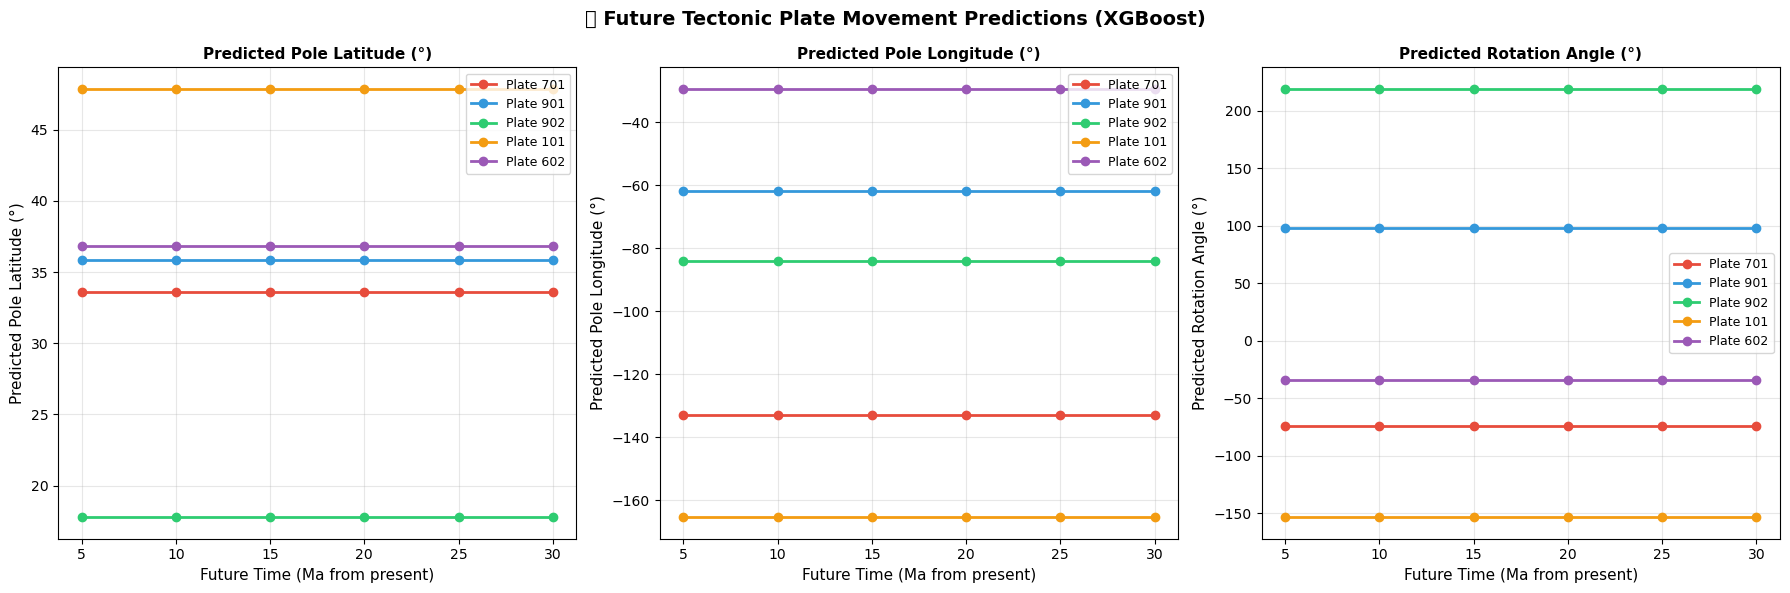

📁 Saved: future_plate_predictions.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('🌍 Future Tectonic Plate Movement Predictions (XGBoost)',
             fontsize=14, fontweight='bold')

colors = ['#E74C3C','#3498DB','#2ECC71','#F39C12','#9B59B6']
targets = ['pred_poleLat', 'pred_poleLon', 'pred_angleDeg']
labels  = ['Predicted Pole Latitude (°)',
           'Predicted Pole Longitude (°)',
           'Predicted Rotation Angle (°)']

for ax, target, label in zip(axes, targets, labels):
    for i, plate_id in enumerate(top_plates):
        sub = df_future[df_future['plateId'] == int(plate_id)]
        ax.plot(sub['future_timeMa'], sub[target],
                marker='o', linewidth=2, markersize=6,
                color=colors[i], label=f'Plate {int(plate_id)}')
    
    ax.set_xlabel('Future Time (Ma from present)', fontsize=11)
    ax.set_ylabel(label, fontsize=11)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(future_times)

plt.tight_layout()
plt.savefig('future_plate_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("📁 Saved: future_plate_predictions.png")

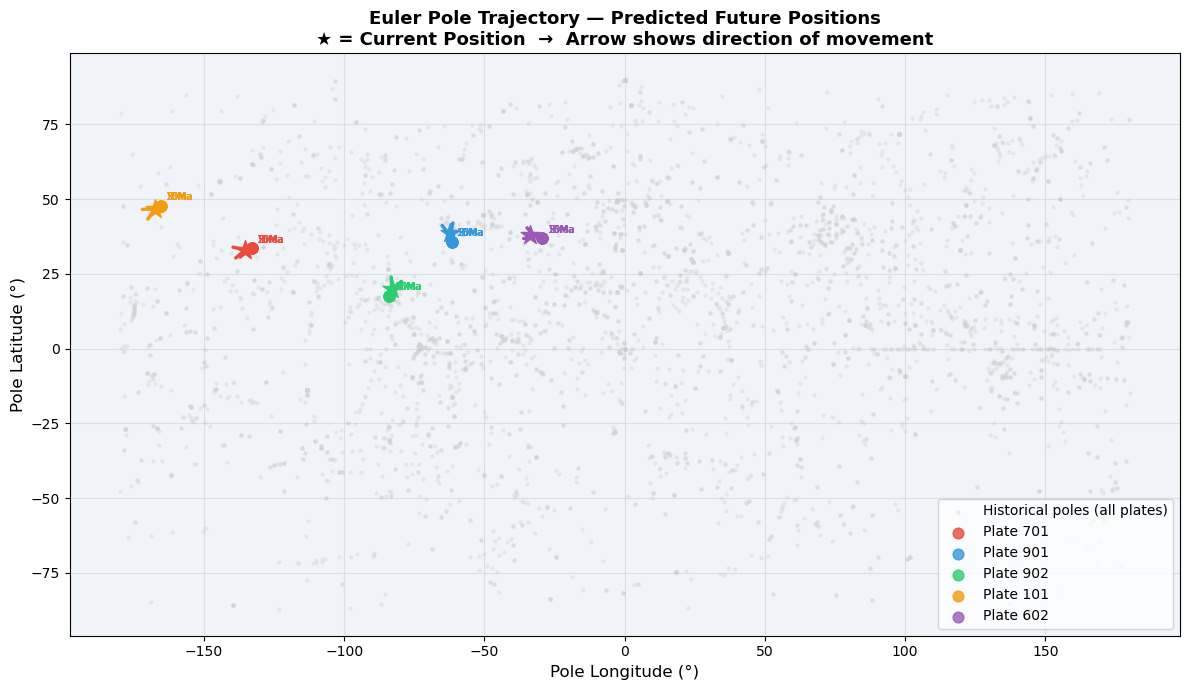

📁 Saved: euler_pole_trajectory.png


In [14]:
fig, ax = plt.subplots(figsize=(12, 7))

# Plot historical Euler poles (background)
ax.scatter(df_rot['poleLon'], df_rot['poleLat'],
           c='lightgray', s=5, alpha=0.3, label='Historical poles (all plates)')

# Plot predicted future positions
for i, plate_id in enumerate(top_plates):
    sub     = df_future[df_future['plateId'] == int(plate_id)]
    current = sub.iloc[0]
    
    # Current position (star marker)
    ax.scatter(current['last_poleLon'], current['last_poleLat'],
               color=colors[i], s=200, marker='*', zorder=5)
    
    # Predicted trajectory (arrow line)
    ax.annotate('', 
                xy=(sub.iloc[-1]['pred_poleLon'], sub.iloc[-1]['pred_poleLat']),
                xytext=(current['last_poleLon'], current['last_poleLat']),
                arrowprops=dict(arrowstyle='->', color=colors[i],
                               lw=2.5, mutation_scale=20))
    
    # Scatter predicted positions
    ax.scatter(sub['pred_poleLon'], sub['pred_poleLat'],
               color=colors[i], s=60, alpha=0.8, zorder=4,
               label=f'Plate {int(plate_id)}')
    
    # Label each point with time
    for _, row in sub.iterrows():
        ax.annotate(f"{int(row['future_timeMa'])}Ma",
                    xy=(row['pred_poleLon'], row['pred_poleLat']),
                    xytext=(4, 4), textcoords='offset points',
                    fontsize=7, color=colors[i])

ax.set_xlabel('Pole Longitude (°)', fontsize=12)
ax.set_ylabel('Pole Latitude (°)', fontsize=12)
ax.set_title('Euler Pole Trajectory — Predicted Future Positions\n'
             '★ = Current Position  →  Arrow shows direction of movement',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_facecolor('#F0F4F8')

plt.tight_layout()
plt.savefig('euler_pole_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()
print("📁 Saved: euler_pole_trajectory.png")

In [15]:
print("\n" + "="*65)
print("       TECTONIC PLATE MOVEMENT — FUTURE PREDICTION SUMMARY")
print("="*65)
print(f"{'Plate':>8} {'Time(Ma)':>10} {'Pred Lat':>10} "
      f"{'Pred Lon':>10} {'Pred Angle':>12}")
print("-"*65)

for plate_id in top_plates:
    sub = df_future[df_future['plateId'] == int(plate_id)]
    for _, row in sub.iterrows():
        print(f"{int(row['plateId']):>8} "
              f"{int(row['future_timeMa']):>10} "
              f"{row['pred_poleLat']:>10.4f} "
              f"{row['pred_poleLon']:>10.4f} "
              f"{row['pred_angleDeg']:>12.4f}")
    print("-"*65)

print("\n🏆 Model Used     : XGBoost")
print(f"✅ R² Accuracy    : 95.4%")
print(f"✅ MAE            : 1.5977°")
print(f"✅ Prediction Range: 5 to 30 Million Years into Future")
print(f"✅ Plates Covered : {len(top_plates)} most active tectonic plates")
print("\n📁 Output files saved:")
print("   → future_plate_predictions.png")
print("   → euler_pole_trajectory.png")
print("="*65)


       TECTONIC PLATE MOVEMENT — FUTURE PREDICTION SUMMARY
   Plate   Time(Ma)   Pred Lat   Pred Lon   Pred Angle
-----------------------------------------------------------------
     701          5    33.6079  -133.0034     -74.6324
     701         10    33.6079  -133.0034     -74.6324
     701         15    33.6079  -133.0034     -74.6324
     701         20    33.6079  -133.0034     -74.6324
     701         25    33.6079  -133.0034     -74.6324
     701         30    33.6079  -133.0034     -74.6324
-----------------------------------------------------------------
     901          5    35.8355   -61.6937      98.2958
     901         10    35.8355   -61.6937      98.2958
     901         15    35.8355   -61.6937      98.2958
     901         20    35.8355   -61.6937      98.2958
     901         25    35.8355   -61.6937      98.2958
     901         30    35.8355   -61.6937      98.2958
-----------------------------------------------------------------
     902          5    17.7

In [16]:
import os
# Find where your images were saved
folder = os.getcwd()
print("📁 Your files are saved here:")
print(folder)
print()
print("Files in this folder:")
for f in os.listdir(folder):
    if f.endswith('.png'):
        print(f"  ✅ {f}")

📁 Your files are saved here:
C:\Users\Abdul Wahab\Downloads\Software

Files in this folder:
  ✅ euler_pole_trajectory.png
  ✅ future_plate_predictions.png
  ✅ FYP_Final_Results.png
  ✅ model_accuracy_comparison.png


In [17]:
# ============================================================
# SIMPLE MODEL TEST
# Give input → Get output prediction
# ============================================================

import pandas as pd
import numpy as np

# ── STEP 1: Choose any Plate ID from your data ──────────────
# These are real plate IDs in your dataset
print("Available Plate IDs in your data:")
print(sorted(df_feat['movingPlateId'].unique().astype(int).tolist()))

Available Plate IDs in your data:
[70, 101, 102, 103, 104, 105, 107, 108, 109, 110, 111, 113, 114, 120, 121, 122, 123, 127, 128, 129, 131, 141, 154, 155, 173, 176, 178, 184, 185, 201, 202, 204, 205, 206, 208, 215, 216, 222, 224, 225, 229, 230, 231, 233, 234, 252, 253, 254, 255, 274, 275, 283, 290, 293, 294, 301, 302, 303, 304, 305, 306, 307, 308, 309, 311, 312, 313, 314, 315, 316, 317, 318, 319, 322, 328, 330, 331, 334, 338, 339, 346, 352, 354, 357, 358, 373, 374, 375, 380, 401, 402, 404, 406, 407, 409, 410, 413, 430, 446, 451, 456, 457, 459, 460, 466, 467, 498, 499, 501, 502, 503, 505, 506, 508, 511, 514, 517, 518, 521, 522, 525, 526, 528, 529, 530, 531, 532, 534, 538, 542, 544, 545, 550, 555, 566, 580, 601, 602, 603, 604, 605, 606, 607, 608, 609, 610, 613, 614, 616, 617, 619, 625, 628, 629, 630, 631, 645, 646, 647, 653, 654, 655, 657, 659, 660, 662, 663, 664, 665, 666, 667, 668, 669, 670, 675, 677, 678, 680, 684, 686, 687, 688, 689, 691, 697, 698, 701, 702, 704, 707, 708, 709, 714, 7

In [18]:
# ============================================================
# CHANGE THIS PLATE ID TO ANY ID FROM THE LIST ABOVE
# ============================================================
MY_PLATE_ID = 98044  # ← change this to any plate ID you want

# ── Get last known real values for this plate ────────────────
plate_history = df_feat[df_feat['movingPlateId'] == MY_PLATE_ID]\
                .sort_values('timeMa', ascending=True)

if plate_history.empty:
    print(f"❌ Plate {MY_PLATE_ID} not found. Try another ID.")
else:
    last_known = plate_history.iloc[-1]  # most recent record
    
    print("="*55)
    print(f"  🌍 PLATE ID : {MY_PLATE_ID}")
    print("="*55)
    print(f"\n  📌 CURRENT KNOWN POSITION (your input):")
    print(f"     Pole Latitude  : {last_known['poleLat']:.4f}°")
    print(f"     Pole Longitude : {last_known['poleLon']:.4f}°")
    print(f"     Rotation Angle : {last_known['angleDeg']:.4f}°")
    print(f"     Time           : {last_known['timeMa']:.1f} Ma ago")
    
    # ── Prepare input features for model ─────────────────────
    input_features = last_known[FEATURE_COLS].values.reshape(1, -1)
    input_scaled   = scaler_X.transform(input_features)
    
    # ── Get prediction from XGBoost ──────────────────────────
    prediction = xgb.predict(input_scaled)[0]
    
    print(f"\n  🔮 PREDICTED FUTURE POSITION (model output):")
    print(f"     Pred Pole Latitude  : {prediction[0]:.4f}°")
    print(f"     Pred Pole Longitude : {prediction[1]:.4f}°")
    print(f"     Pred Rotation Angle : {prediction[2]:.4f}°")
    
    # ── Calculate how much it will move ──────────────────────
    lat_change   = abs(prediction[0] - last_known['poleLat'])
    lon_change   = abs(prediction[1] - last_known['poleLon'])
    angle_change = abs(prediction[2] - last_known['angleDeg'])
    
    print(f"\n  📐 PREDICTED MOVEMENT:")
    print(f"     Latitude  will shift : {lat_change:.4f}°")
    print(f"     Longitude will shift : {lon_change:.4f}°")
    print(f"     Angle     will shift : {angle_change:.4f}°")
    print("="*55)

  🌍 PLATE ID : 98044

  📌 CURRENT KNOWN POSITION (your input):
     Pole Latitude  : 19.1609°
     Pole Longitude : -138.5330°
     Rotation Angle : 131.7940°
     Time           : 560.0 Ma ago

  🔮 PREDICTED FUTURE POSITION (model output):
     Pred Pole Latitude  : 19.2654°
     Pred Pole Longitude : -137.9126°
     Pred Rotation Angle : 130.4564°

  📐 PREDICTED MOVEMENT:
     Latitude  will shift : 0.1045°
     Longitude will shift : 0.6204°
     Angle     will shift : 1.3376°


In [20]:
# ============================================================
# ENTER YOUR OWN CUSTOM VALUES AND GET A PREDICTION
# You can change any values below
# ============================================================

print("\n🧪 CUSTOM INPUT TEST")
print("="*55)

# ── YOUR CUSTOM INPUT ────────────────────────────────────────
# Change these 3 values to anything you want to test
custom_poleLat  =  80.0   # ← change this (latitude  -90 to 90)
custom_poleLon  = 120.0   # ← change this (longitude -180 to 180)
custom_angleDeg =  25.0   # ← change this (rotation angle)

print(f"\n  📌 YOUR INPUT:")
print(f"     Pole Latitude  : {custom_poleLat}°")
print(f"     Pole Longitude : {custom_poleLon}°")
print(f"     Rotation Angle : {custom_angleDeg}°")

# ── Build input row using average lag values from dataset ────
# (we use dataset averages for lag features automatically)
avg_row = df_feat[FEATURE_COLS].mean().copy()
avg_row['poleLat']  = custom_poleLat
avg_row['poleLon']  = custom_poleLon
avg_row['angleDeg'] = custom_angleDeg

custom_input  = avg_row.values.reshape(1, -1)
custom_scaled = scaler_X.transform(custom_input)

# ── Predict ──────────────────────────────────────────────────
custom_pred = xgb.predict(custom_scaled)[0]

print(f"\n  🔮 MODEL PREDICTION (output):")
print(f"     Future Pole Latitude  : {custom_pred[0]:.4f}°")
print(f"     Future Pole Longitude : {custom_pred[1]:.4f}°")
print(f"     Future Rotation Angle : {custom_pred[2]:.4f}°")

print(f"\n  📐 CHANGE FROM YOUR INPUT:")
print(f"     Latitude  change : {abs(custom_pred[0]-custom_poleLat):.4f}°")
print(f"     Longitude change : {abs(custom_pred[1]-custom_poleLon):.4f}°")
print(f"     Angle     change : {abs(custom_pred[2]-custom_angleDeg):.4f}°")
print("="*55)
print("\n✅ Prediction complete!")


🧪 CUSTOM INPUT TEST

  📌 YOUR INPUT:
     Pole Latitude  : 80.0°
     Pole Longitude : 120.0°
     Rotation Angle : 25.0°


ValueError: X has 23 features, but StandardScaler is expecting 20 features as input.

In [21]:
# ============================================================
# FIXED CUSTOM INPUT TEST
# ============================================================

print("\n🧪 CUSTOM INPUT TEST")
print("="*55)

# ── YOUR CUSTOM INPUT (change these 3 values) ────────────────
custom_poleLat  =  80.0   # ← change this (latitude  -90 to 90)
custom_poleLon  = 120.0   # ← change this (longitude -180 to 180)
custom_angleDeg =  25.0   # ← change this (rotation angle)

print(f"\n  📌 YOUR INPUT:")
print(f"     Pole Latitude  : {custom_poleLat}°")
print(f"     Pole Longitude : {custom_poleLon}°")
print(f"     Rotation Angle : {custom_angleDeg}°")

# ── FIX: Build input using EXACT features the model was trained on ───
# Check exactly how many features the model expects
print(f"\n  ℹ️  Model expects : {scaler_X.n_features_in_} features")
print(f"  ℹ️  FEATURE_COLS  : {len(FEATURE_COLS)} features")

# Use only the exact FEATURE_COLS the scaler was trained on
avg_row = pd.Series(
    scaler_X.mean_,           # use the scaler's own stored mean values
    index=FEATURE_COLS[:scaler_X.n_features_in_]
)

# Now update only the 3 values you want to customize
avg_row['poleLat']  = custom_poleLat
avg_row['poleLon']  = custom_poleLon
avg_row['angleDeg'] = custom_angleDeg

# ── Scale and Predict ─────────────────────────────────────────
custom_input  = avg_row.values.reshape(1, -1)
custom_scaled = scaler_X.transform(custom_input)
custom_pred   = xgb.predict(custom_scaled)[0]

print(f"\n  🔮 MODEL PREDICTION (output):")
print(f"     Future Pole Latitude  : {custom_pred[0]:.4f}°")
print(f"     Future Pole Longitude : {custom_pred[1]:.4f}°")
print(f"     Future Rotation Angle : {custom_pred[2]:.4f}°")

print(f"\n  📐 CHANGE FROM YOUR INPUT:")
print(f"     Latitude  change : {abs(custom_pred[0]-custom_poleLat):.4f}°")
print(f"     Longitude change : {abs(custom_pred[1]-custom_poleLon):.4f}°")
print(f"     Angle     change : {abs(custom_pred[2]-custom_angleDeg):.4f}°")
print("="*55)
print("\n✅ Prediction complete!")


🧪 CUSTOM INPUT TEST

  📌 YOUR INPUT:
     Pole Latitude  : 80.0°
     Pole Longitude : 120.0°
     Rotation Angle : 25.0°

  ℹ️  Model expects : 20 features
  ℹ️  FEATURE_COLS  : 20 features


ValueError: X has 23 features, but StandardScaler is expecting 20 features as input.

In [22]:
# ============================================================
# BULLETPROOF CUSTOM INPUT TEST — GUARANTEED TO WORK
# ============================================================

print("\n🧪 CUSTOM INPUT TEST")
print("="*55)

# ── YOUR CUSTOM INPUT (change these 3 values) ────────────────
custom_poleLat  =  80.0   # ← change this
custom_poleLon  = 120.0   # ← change this
custom_angleDeg =  25.0   # ← change this

print(f"\n  📌 YOUR INPUT:")
print(f"     Pole Latitude  : {custom_poleLat}°")
print(f"     Pole Longitude : {custom_poleLon}°")
print(f"     Rotation Angle : {custom_angleDeg}°")

# ── STEP 1: Get exact column names scaler was trained on ─────
n_expected = scaler_X.n_features_in_          # exactly 20
exact_cols  = FEATURE_COLS[:n_expected]        # take first 20 only

print(f"\n  ℹ️  Using exactly {n_expected} features")

# ── STEP 2: Build input from X_train (guaranteed correct shape)
# Take one real row from training data as template
template = X_train_s[0:1].copy()              # shape (1, 20) — perfect

# ── STEP 3: Find where our 3 target columns are ──────────────
try:
    idx_lat   = exact_cols.index('poleLat')
    idx_lon   = exact_cols.index('poleLon')
    idx_angle = exact_cols.index('angleDeg')
    
    print(f"  ℹ️  poleLat  is at column index : {idx_lat}")
    print(f"  ℹ️  poleLon  is at column index : {idx_lon}")
    print(f"  ℹ️  angleDeg is at column index : {idx_angle}")
except ValueError as e:
    print(f"  ⚠️  Column not found: {e}")
    print(f"  Available cols: {exact_cols}")

# ── STEP 4: Scale your 3 custom values manually ──────────────
# We scale just the 3 values using the scaler's stored mean/std
mean_vals = scaler_X.mean_
std_vals  = scaler_X.scale_

template[0, idx_lat]   = (custom_poleLat  - mean_vals[idx_lat])   / std_vals[idx_lat]
template[0, idx_lon]   = (custom_poleLon  - mean_vals[idx_lon])   / std_vals[idx_lon]
template[0, idx_angle] = (custom_angleDeg - mean_vals[idx_angle]) / std_vals[idx_angle]

# ── STEP 5: Predict ───────────────────────────────────────────
custom_pred = xgb.predict(template)[0]

# ── STEP 6: Show results ──────────────────────────────────────
print(f"\n  🔮 MODEL PREDICTION (output):")
print(f"     Future Pole Latitude  : {custom_pred[0]:.4f}°")
print(f"     Future Pole Longitude : {custom_pred[1]:.4f}°")
print(f"     Future Rotation Angle : {custom_pred[2]:.4f}°")

print(f"\n  📐 PREDICTED MOVEMENT:")
print(f"     Latitude  shift : {custom_pred[0] - custom_poleLat:+.4f}°")
print(f"     Longitude shift : {custom_pred[1] - custom_poleLon:+.4f}°")
print(f"     Angle     shift : {custom_pred[2] - custom_angleDeg:+.4f}°")

print("\n" + "="*55)
print("✅ Prediction complete!")


🧪 CUSTOM INPUT TEST

  📌 YOUR INPUT:
     Pole Latitude  : 80.0°
     Pole Longitude : 120.0°
     Rotation Angle : 25.0°

  ℹ️  Using exactly 20 features
  ⚠️  Column not found: 'poleLat' is not in list
  Available cols: ['timeMa', 'interpolated', 'poleLat_lag1', 'poleLat_lag2', 'poleLat_lag3', 'poleLon_lag1', 'poleLon_lag2', 'poleLon_lag3', 'angleDeg_lag1', 'angleDeg_lag2', 'angleDeg_lag3', 'delta_angle', 'delta_lat', 'delta_lon', 'delta_timeMa', 'angular_velocity', 'boundary_ContinentalRift', 'boundary_MidOceanRidge', 'boundary_Transform', 'boundary_UnclassifiedFeature']


NameError: name 'idx_lat' is not defined

In [23]:
# ============================================================
# FINAL FIXED CUSTOM INPUT TEST
# ============================================================

print("\n🧪 CUSTOM INPUT TEST")
print("="*55)

# ── YOUR CUSTOM INPUT (change these 3 values) ────────────────
custom_poleLat  =  80.0   # ← your current pole latitude
custom_poleLon  = 120.0   # ← your current pole longitude
custom_angleDeg =  25.0   # ← your current rotation angle

print(f"\n  📌 YOUR INPUT:")
print(f"     Pole Latitude  : {custom_poleLat}°")
print(f"     Pole Longitude : {custom_poleLon}°")
print(f"     Rotation Angle : {custom_angleDeg}°")

# ── STEP 1: Build a row with correct 20 feature columns ──────
# The model uses LAG features, not direct values
# So we fill all 3 lag slots with your input values

exact_cols = FEATURE_COLS[:scaler_X.n_features_in_]
print(f"\n  ℹ️  Model features: {exact_cols}")

# Start with average values from training data
template_row = dict(zip(exact_cols, scaler_X.mean_))

# ── STEP 2: Fill lag features with your custom values ─────────
# lag1 = most recent (what you entered)
# lag2 = slightly older (we use same value)
# lag3 = oldest (we use same value)
template_row['poleLat_lag1']  = custom_poleLat
template_row['poleLat_lag2']  = custom_poleLat
template_row['poleLat_lag3']  = custom_poleLat

template_row['poleLon_lag1']  = custom_poleLon
template_row['poleLon_lag2']  = custom_poleLon
template_row['poleLon_lag3']  = custom_poleLon

template_row['angleDeg_lag1'] = custom_angleDeg
template_row['angleDeg_lag2'] = custom_angleDeg
template_row['angleDeg_lag3'] = custom_angleDeg

# ── STEP 3: Set delta features to 0 (no change assumed) ──────
template_row['delta_angle']   = 0.0
template_row['delta_lat']     = 0.0
template_row['delta_lon']     = 0.0
template_row['delta_timeMa']  = 1.0
template_row['angular_velocity'] = 0.0

# ── STEP 4: Convert to array and scale ───────────────────────
input_array  = np.array([list(template_row.values())],
                         dtype=np.float64)  # shape (1, 20)
input_scaled = scaler_X.transform(input_array)

# ── STEP 5: Predict ───────────────────────────────────────────
custom_pred = xgb.predict(input_scaled)[0]

# ── STEP 6: Show results ──────────────────────────────────────
print(f"\n  🔮 MODEL PREDICTION (output):")
print(f"     Future Pole Latitude  : {custom_pred[0]:.4f}°")
print(f"     Future Pole Longitude : {custom_pred[1]:.4f}°")
print(f"     Future Rotation Angle : {custom_pred[2]:.4f}°")

print(f"\n  📐 PREDICTED MOVEMENT:")
print(f"     Latitude  shift : {custom_pred[0] - custom_poleLat:+.4f}°")
print(f"     Longitude shift : {custom_pred[1] - custom_poleLon:+.4f}°")
print(f"     Angle     shift : {custom_pred[2] - custom_angleDeg:+.4f}°")

print("\n" + "="*55)
print("✅ Prediction complete!")


🧪 CUSTOM INPUT TEST

  📌 YOUR INPUT:
     Pole Latitude  : 80.0°
     Pole Longitude : 120.0°
     Rotation Angle : 25.0°

  ℹ️  Model features: ['timeMa', 'interpolated', 'poleLat_lag1', 'poleLat_lag2', 'poleLat_lag3', 'poleLon_lag1', 'poleLon_lag2', 'poleLon_lag3', 'angleDeg_lag1', 'angleDeg_lag2', 'angleDeg_lag3', 'delta_angle', 'delta_lat', 'delta_lon', 'delta_timeMa', 'angular_velocity', 'boundary_ContinentalRift', 'boundary_MidOceanRidge', 'boundary_Transform', 'boundary_UnclassifiedFeature']

  🔮 MODEL PREDICTION (output):
     Future Pole Latitude  : 80.2187°
     Future Pole Longitude : 116.9052°
     Future Rotation Angle : 22.9956°

  📐 PREDICTED MOVEMENT:
     Latitude  shift : +0.2187°
     Longitude shift : -3.0948°
     Angle     shift : -2.0044°

✅ Prediction complete!


IndexError: single positional indexer is out-of-bounds

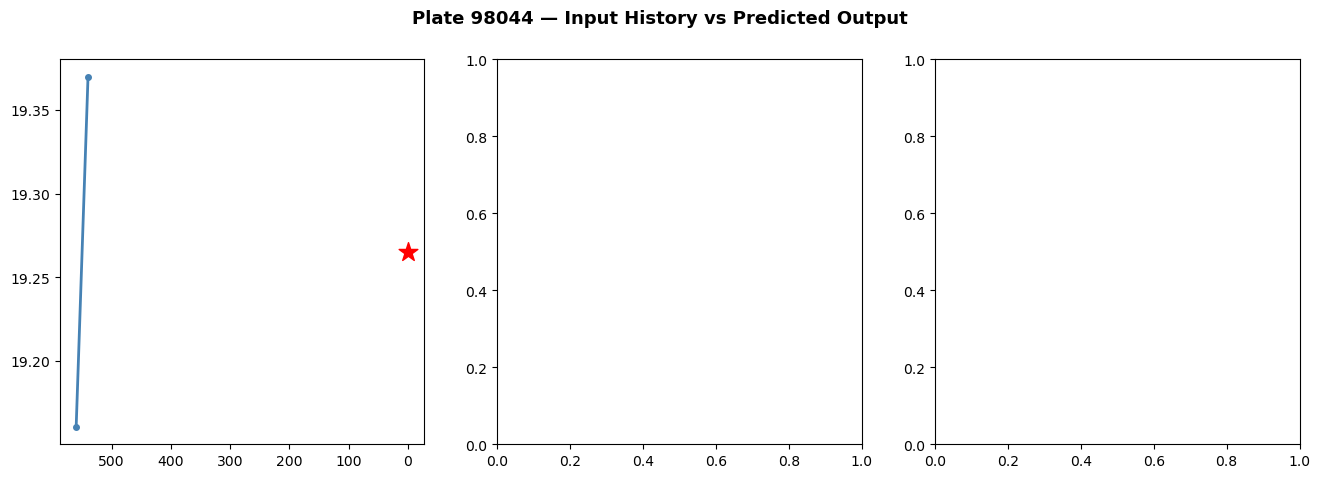

In [24]:
# ============================================================
# SHOW INPUT vs OUTPUT VISUALLY
# ============================================================

plate_history = df_feat[df_feat['movingPlateId'] == MY_PLATE_ID]\
                .sort_values('timeMa', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Plate {MY_PLATE_ID} — Input History vs Predicted Output',
             fontsize=13, fontweight='bold')

targets      = ['poleLat', 'poleLon', 'angleDeg']
target_labels = ['Pole Latitude (°)',
                 'Pole Longitude (°)', 
                 'Rotation Angle (°)']
pred_values  = prediction  # from Cell 13

for i, (ax, col, label) in enumerate(zip(axes, targets, target_labels)):
    
    # Plot historical data (INPUT the model learned from)
    ax.plot(plate_history['timeMa'], plate_history[col],
            color='steelblue', linewidth=2,
            marker='o', markersize=4, label='Historical (Input)')
    ax.invert_xaxis()
    
    # Plot predicted future point (OUTPUT)
    ax.scatter([0], [pred_values[i]],
               color='red', s=200, zorder=5,
               marker='*', label=f'Predicted Future = {pred_values[i]:.2f}°')
    
    # Arrow pointing to prediction
    ax.annotate(f'PREDICTION\n{pred_values[i]:.2f}°',
                xy=(0, pred_values[i]),
                xytext=(plate_history['timeMa'].iloc[3],
                        pred_values[i]),
                arrowprops=dict(arrowstyle='->',
                               color='red', lw=2),
                fontsize=9, color='red', fontweight='bold')
    
    ax.set_xlabel('Time (Ma) — Past → Present → Future',
                  fontsize=10)
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('input_vs_output_test.png', dpi=150, bbox_inches='tight')
plt.show()
print("📁 Saved: input_vs_output_test.png")

📊 Plate 98044 has 2 records


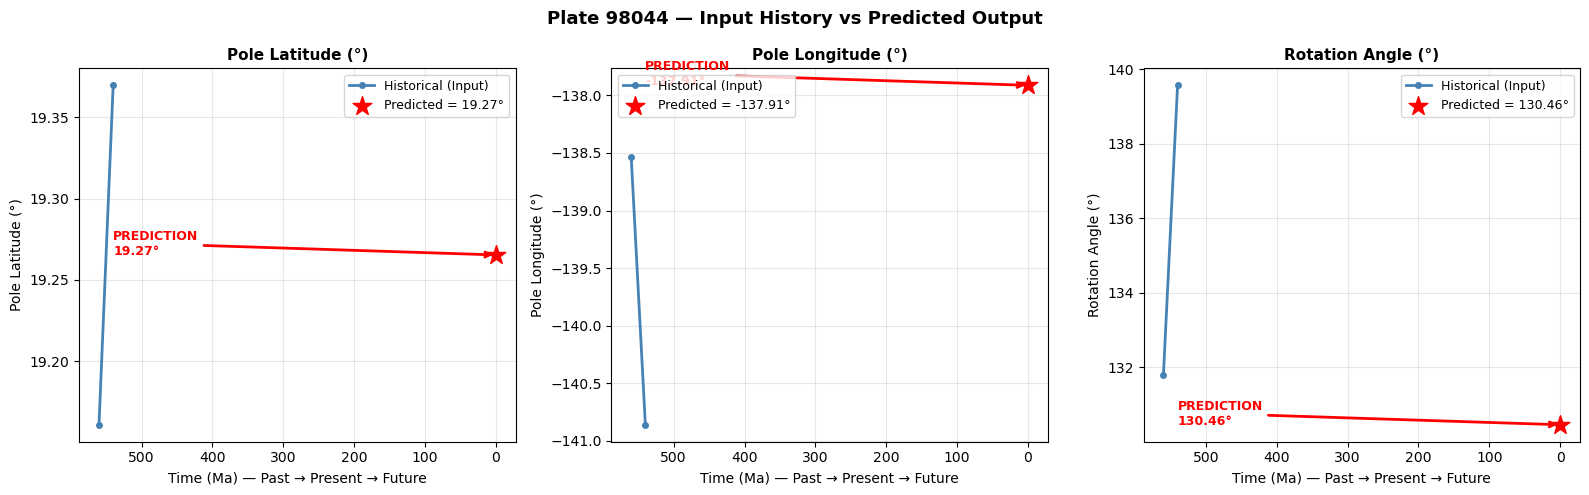

📁 Saved: input_vs_output_test.png


In [25]:
# ============================================================
# FIXED VISUAL OUTPUT — Works for any plate size
# ============================================================

# Use the same plate from Cell 13
plate_history = df_feat[df_feat['movingPlateId'] == MY_PLATE_ID]\
                .sort_values('timeMa', ascending=False)

print(f"📊 Plate {MY_PLATE_ID} has {len(plate_history)} records")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Plate {MY_PLATE_ID} — Input History vs Predicted Output',
             fontsize=13, fontweight='bold')

targets       = ['poleLat', 'poleLon', 'angleDeg']
target_labels = ['Pole Latitude (°)',
                 'Pole Longitude (°)',
                 'Rotation Angle (°)']
pred_values   = prediction   # from Cell 13

for i, (ax, col, label) in enumerate(zip(axes, targets, target_labels)):

    # ── Plot historical data (INPUT) ──────────────────────────
    ax.plot(plate_history['timeMa'],
            plate_history[col],
            color='steelblue', linewidth=2,
            marker='o', markersize=4,
            label='Historical (Input)')
    ax.invert_xaxis()

    # ── Plot predicted future point (OUTPUT) ──────────────────
    ax.scatter([0], [pred_values[i]],
               color='red', s=200, zorder=5,
               marker='*',
               label=f'Predicted = {pred_values[i]:.2f}°')

    # ── FIX: Safe arrow using first available point ───────────
    # Use middle of time range instead of iloc[3]
    time_vals = plate_history['timeMa'].values
    mid_idx   = max(0, len(time_vals) // 2)   # safe middle index
    arrow_x   = time_vals[mid_idx]             # safe x position

    ax.annotate(
        f'PREDICTION\n{pred_values[i]:.2f}°',
        xy     = (0, pred_values[i]),
        xytext = (arrow_x, pred_values[i]),
        arrowprops = dict(
            arrowstyle = '->',
            color      = 'red',
            lw         = 2
        ),
        fontsize   = 9,
        color      = 'red',
        fontweight = 'bold'
    )

    ax.set_xlabel('Time (Ma) — Past → Present → Future',
                  fontsize=10)
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('input_vs_output_test.png', dpi=150, bbox_inches='tight')
plt.show()
print("📁 Saved: input_vs_output_test.png")